# Noisy-LJ rollout in a normalized latent space

This experiment isolates noisy LJ from the shared simulator. The edge-aware autoencoder and latent propagator are trained only on noisy-LJ trajectories. Positions and predicted displacements use the fixed normalized coordinate system. The autonomous propagator observes only $z(1)$ and $z(5)$, receives no frame/progress variable, and is trained with one-step supervision.

In [1]:
%matplotlib inline
import os, sys
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT/'src'/'lss').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT/'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT/'src'))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from lss.latent.experiment import run_latent_experiment, seed_everything
from lss.latent.simulation import pearson_r, r2_score
from lss.plotting import PAPER_COLORS, apply_editorial_style, dataset_color, style_axes
from lss.utils import resolve_device
apply_editorial_style()
plt.rcParams.update({'figure.dpi': 180, 'savefig.dpi': 400})
DEVICE = resolve_device('auto')
print(f'Device: {DEVICE}')

Device: cuda


/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
SEED = 34234
FORCE_TRAIN = True
TRAIN_NETWORKS = 150
VAL_NETWORKS = 25
TRAIN_STEPS_PER_SIM = 194
AE_MAX_EPOCHS = 50
DYN_MAX_EPOCHS = 80
PATIENCE = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
LATENT_DIM = 8
OBSERVED_FRAMES = (1, 5)
ROLLOUT_STEPS = [25, 50, 75, 100, 125, 150, 175, 199]
AE_MAX_FRAMES_PER_SIM = max(ROLLOUT_STEPS) + 1

DATA = PROJECT_ROOT/'data'/'lj-noisy-eps0.01-sigma1.0-cutoff1.122_200sims_200frames.pt'
if not DATA.is_file():
    raise FileNotFoundError(DATA)
OUTPUT = PROJECT_ROOT/'notebooks'/'results'/'07_noisy_lj_normalized_context_rollout'
OUTPUT.mkdir(parents=True, exist_ok=True)
MODEL_CACHE = OUTPUT/'noisy_lj_8d_normalized_box_no_static_context_v10.pt'

AE_CONFIG = {
    'latent_dim': LATENT_DIM, 'latent_tokens': 32, 'hidden_size': 64,
    'model': 'single_stage_attention', 'edge_feature_dim': 13, 'batch_graphs': 256,
    'target_mode': 'normalized_delta', 'node_feature_mode': 'normalized_delta',
    'max_train_frames_per_sim': AE_MAX_FRAMES_PER_SIM, 'val_frame_skip': 1,
    'max_val_frames_per_sim': AE_MAX_FRAMES_PER_SIM,
    'max_epochs': AE_MAX_EPOCHS, 'patience': PATIENCE, 'lr': 2e-4, 'weight_decay': 1e-5,
    'balance_sources': False, 'mix_sources': False,
}
PROPAGATOR_CONFIG = {
    'max_train_transitions_per_sim': TRAIN_STEPS_PER_SIM,
    'max_epochs': DYN_MAX_EPOCHS, 'patience': 15, 'lr': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY,
    'hidden_size': 32, 'objective': 'fixed_history_one_step', 'model': 'fixed_velocity_residual_mlp',
    'loss': 'delta', 'step_stride': 1, 'fixed_observed_frames': OBSERVED_FRAMES, 'multistep_horizons': [1],
    'train_trajectories_per_source': {'lj_noisy': TRAIN_NETWORKS},
    'val_trajectories_per_source': {'lj_noisy': VAL_NETWORKS},
    'mix_sources': False, 'balance_sources': False, 'use_static_context': False,
    'rollout_eval_every_epoch': True,
    'rollout_eval_source': 'lj_noisy', 'rollout_eval_horizons': [100, 199],
    'rollout_eval_sims_per_source': 20,
}
print({
    'data': str(DATA), 'train': TRAIN_NETWORKS, 'validation': VAL_NETWORKS,
    'test': 200-TRAIN_NETWORKS-VAL_NETWORKS, 'latent_dim': LATENT_DIM,
    'ae_frames_per_trajectory': AE_MAX_FRAMES_PER_SIM,
    'observed_frames': OBSERVED_FRAMES, 'physical_static_context': False,
    'cache': str(MODEL_CACHE),
})

{'data': '/home/alexz/Documents/course_project/data/lj-noisy-eps0.01-sigma1.0-cutoff1.122_200sims_200frames.pt', 'train': 150, 'validation': 25, 'test': 25, 'latent_dim': 8, 'ae_frames_per_trajectory': 200, 'observed_frames': (1, 5), 'physical_static_context': False, 'cache': '/home/alexz/Documents/course_project/notebooks/results/07_noisy_lj_normalized_context_rollout/noisy_lj_8d_normalized_box_no_static_context_v10.pt'}


## Train the noisy-LJ autoencoder and propagator

In [3]:
experiment_config = {
    'dataset_name': 'lj_noisy', 'train_count': TRAIN_NETWORKS, 'val_count': VAL_NETWORKS,
    'split_seed': SEED, 'model_seed': SEED, 'repeat_idx': 1,
    'split_stratify_temperature': False, 'min_train_p_ratio': None,
    'device': str(DEVICE), 'pos_dim': 2, 'frame_skip': 1, 'train_frame_start_order': 0,
    'edge_multiplicity': 1, 'edge_vector_dim': 2, 'edge_mode': 'stored',
    'coordinate_normalization': 'position_normalization',
    'edge_feature_schema': 'physical_static_normalized_edge_changes_v3',
    'ae_config': AE_CONFIG, 'propagator_config': PROPAGATOR_CONFIG,
    'rollout_steps_grid': ROLLOUT_STEPS,
    'rollout_eval_splits': ['test'], 'rollout_eval_max_sims_by_split': {'test': 50},
    'rollout_eval_source': 'lj_noisy',
    'early_stop_min_delta': 1e-5,
    'should_rollout': True, 'should_train_propagator': True,
    'force_train': FORCE_TRAIN,
    'cache_path': str(MODEL_CACHE), 'cache_require_matching_config': True,
    'force_train_autoencoder': True,
}
source = {
    'dataset_name': 'lj_noisy', 'source_name': 'lj_noisy',
    'label': 'noisy LJ | normalized coordinates, no static context',
    'path': str(DATA), 'train_count': TRAIN_NETWORKS, 'val_count': VAL_NETWORKS,
    'edge_multiplicity': 1, 'edge_vector_dim': 2,
}
seed_everything(SEED)
result = run_latent_experiment(source, experiment_config, device=DEVICE)
display(result['split_info'])
display(result['ae_history'].tail())
display(result['dyn_history'].tail())


=== noisy LJ | normalized coordinates, no static context ===
                                                 source                                                                                                 path  total  train  val  test
lj-noisy-eps0.01-sigma1.0-cutoff1.122_200sims_200frames /home/alexz/Documents/course_project/data/lj-noisy-eps0.01-sigma1.0-cutoff1.122_200sims_200frames.pt    200    150   25    25


KeyboardInterrupt: 

## Normalization and context audit

In [ ]:
graph = result['train_data'][0][0]
bounds = np.array([graph.box.x1, graph.box.x2, graph.box.y1, graph.box.y2], dtype=float)
reference_half_extent = torch.as_tensor(graph.reference_length_scale).detach().cpu().numpy().reshape(-1)
has_original_context = hasattr(graph, 'reference_context_positions') and hasattr(graph, 'reference_context_edge_attr')
audit = pd.DataFrame([{
    'coordinate_system': getattr(graph, 'coordinate_normalization', 'missing'),
    'x_min': bounds[0], 'x_max': bounds[1], 'y_min': bounds[2], 'y_max': bounds[3],
    'stored_reference_half_extent_x': reference_half_extent[0],
    'stored_reference_half_extent_y': reference_half_extent[1],
    'original_graph_context': has_original_context,
    'max_observed_frame': max(result['params']['fixed_observed_frames']),
    'latent_dim': result['params']['latent_dim'],
}])
assert audit.max_observed_frame.iloc[0] <= 5
assert has_original_context
assert np.all(np.isfinite(reference_half_extent)) and np.all(reference_half_extent > 0)
display(audit.round(4))

,coordinate_system,x_min,x_max,y_min,y_max,stored_reference_half_extent_x,stored_reference_half_extent_y,original_graph_context,max_observed_frame,latent_dim
0,position_normalization,-1.0,1.0,-1.0,1.0,8.0318,7.9804,True,5,8


## Held-out rollout performance

,representation,estimator,rollout_steps,n_networks,p_ratio_r2,pearson_r,position_mse
1,direct Autoencoder,directional-side endpoint,50,25,0.6364,0.8612,0.0
3,direct Autoencoder,directional-side endpoint,100,25,0.8284,0.9306,0.0
5,direct Autoencoder,directional-side endpoint,150,25,0.7979,0.8943,0.0
7,direct Autoencoder,directional-side endpoint,199,25,0.6920,0.8649,0.0
9,direct Autoencoder,trajectory fit,50,25,0.7167,0.9292,0.0
11,direct Autoencoder,trajectory fit,100,25,0.8150,0.9244,0.0
13,direct Autoencoder,trajectory fit,150,25,0.7839,0.8937,0.0
15,direct Autoencoder,trajectory fit,199,25,0.6672,0.8475,0.0
17,latent rollout,directional-side endpoint,50,25,0.2959,0.6012,0.0
19,latent rollout,directional-side endpoint,100,25,0.3949,0.7420,0.0


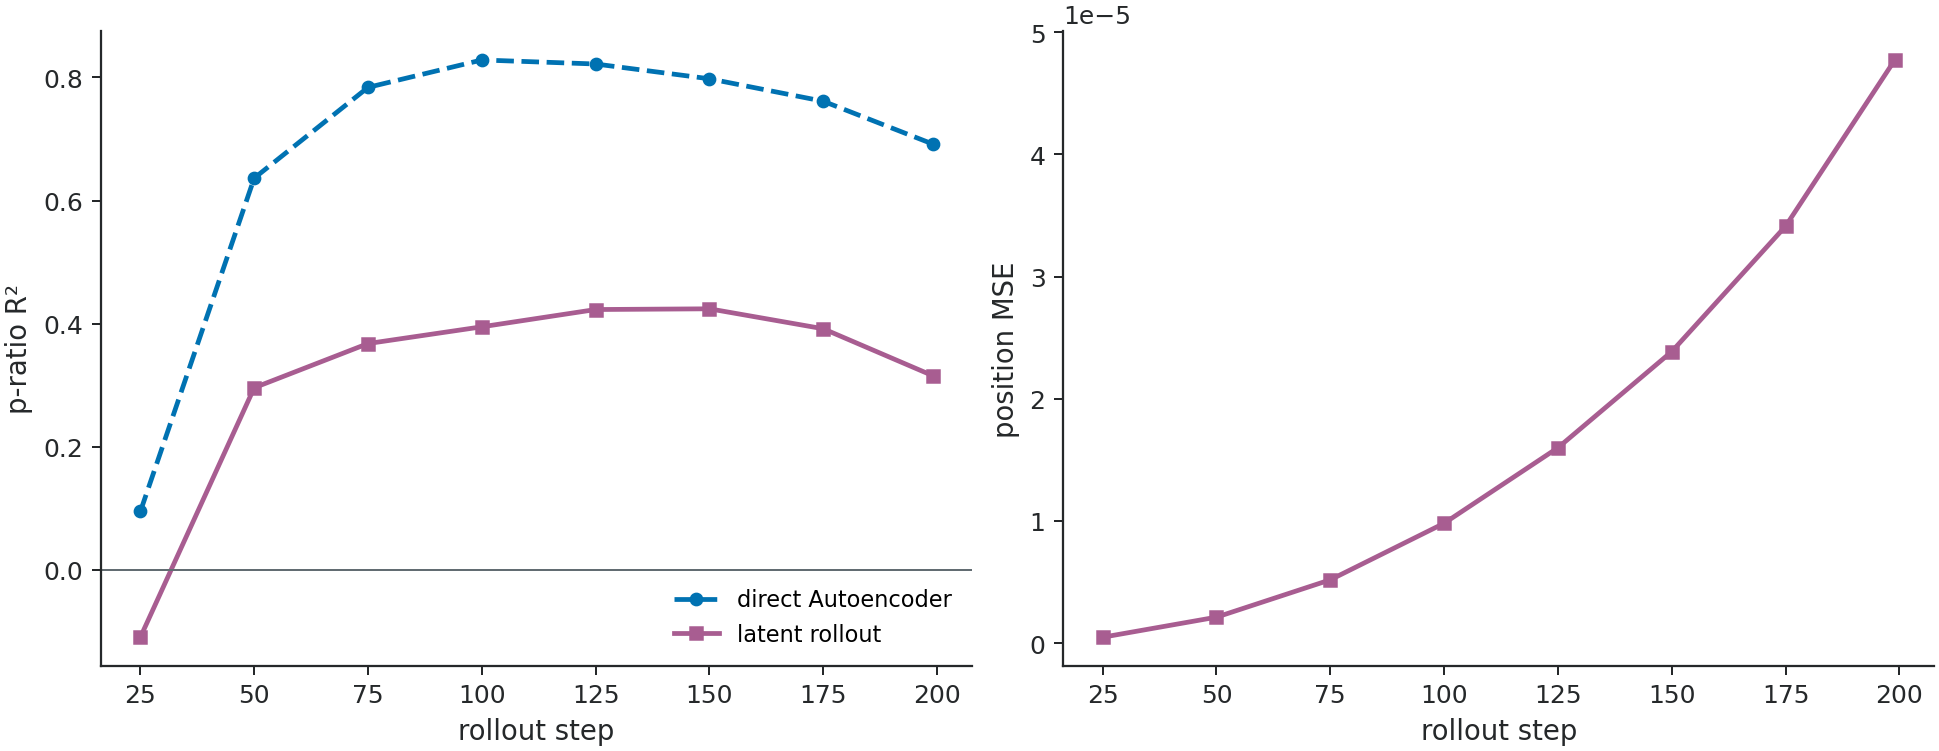

In [ ]:
rollout = result['rollout_rows'].query("split == 'test'").copy()
direct = result['ae_reconstruction_rows'].query("split == 'test'").copy()
summary_rows = []
for representation, frame in [('direct Autoencoder', direct), ('latent rollout', rollout)]:
    for estimator, true_col, pred_col in [
        ('directional-side endpoint', 'endpoint_true_p_ratio', 'endpoint_pred_p_ratio'),
        ('trajectory fit', 'true_p_ratio', 'pred_p_ratio'),
    ]:
        for step, group in frame.groupby('rollout_steps'):
            valid = group[[true_col, pred_col]].replace([np.inf, -np.inf], np.nan).dropna()
            errors = group.final_pos_mse.replace([np.inf, -np.inf], np.nan).dropna()
            summary_rows.append({
                'representation': representation, 'estimator': estimator,
                'rollout_steps': int(step), 'n_networks': len(valid),
                'p_ratio_r2': r2_score(valid[true_col], valid[pred_col]) if len(valid) > 1 else np.nan,
                'pearson_r': pearson_r(valid[true_col], valid[pred_col]) if len(valid) > 1 else np.nan,
                'position_mse': errors.mean(),
            })
summary = pd.DataFrame(summary_rows)
display(summary[summary.rollout_steps.isin([50, 100, 150, 199])].round(4))

headline = summary[summary.estimator.eq('directional-side endpoint')]
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.2), constrained_layout=True)
for representation, color, marker, linestyle in [
    ('direct Autoencoder', PAPER_COLORS['blue'], 'o', '--'),
    ('latent rollout', dataset_color('lj_noisy'), 's', '-'),
]:
    group = headline[headline.representation.eq(representation)].sort_values('rollout_steps')
    axes[0].plot(group.rollout_steps, group.p_ratio_r2, color=color, marker=marker,
                 linestyle=linestyle, linewidth=1.9, markersize=4.5, label=representation)
rollout_error = headline[headline.representation.eq('latent rollout')].sort_values('rollout_steps')
axes[1].plot(rollout_error.rollout_steps, rollout_error.position_mse,
             color=dataset_color('lj_noisy'), marker='s', linewidth=1.9, markersize=4.5)
axes[0].axhline(0, color=PAPER_COLORS['slate'], linewidth=.8)
style_axes(axes[0], xlabel='rollout step', ylabel='p-ratio R²', legend=True)
style_axes(axes[1], xlabel='rollout step', ylabel='position MSE', legend=False)
plt.show()

## Held-out network scatter

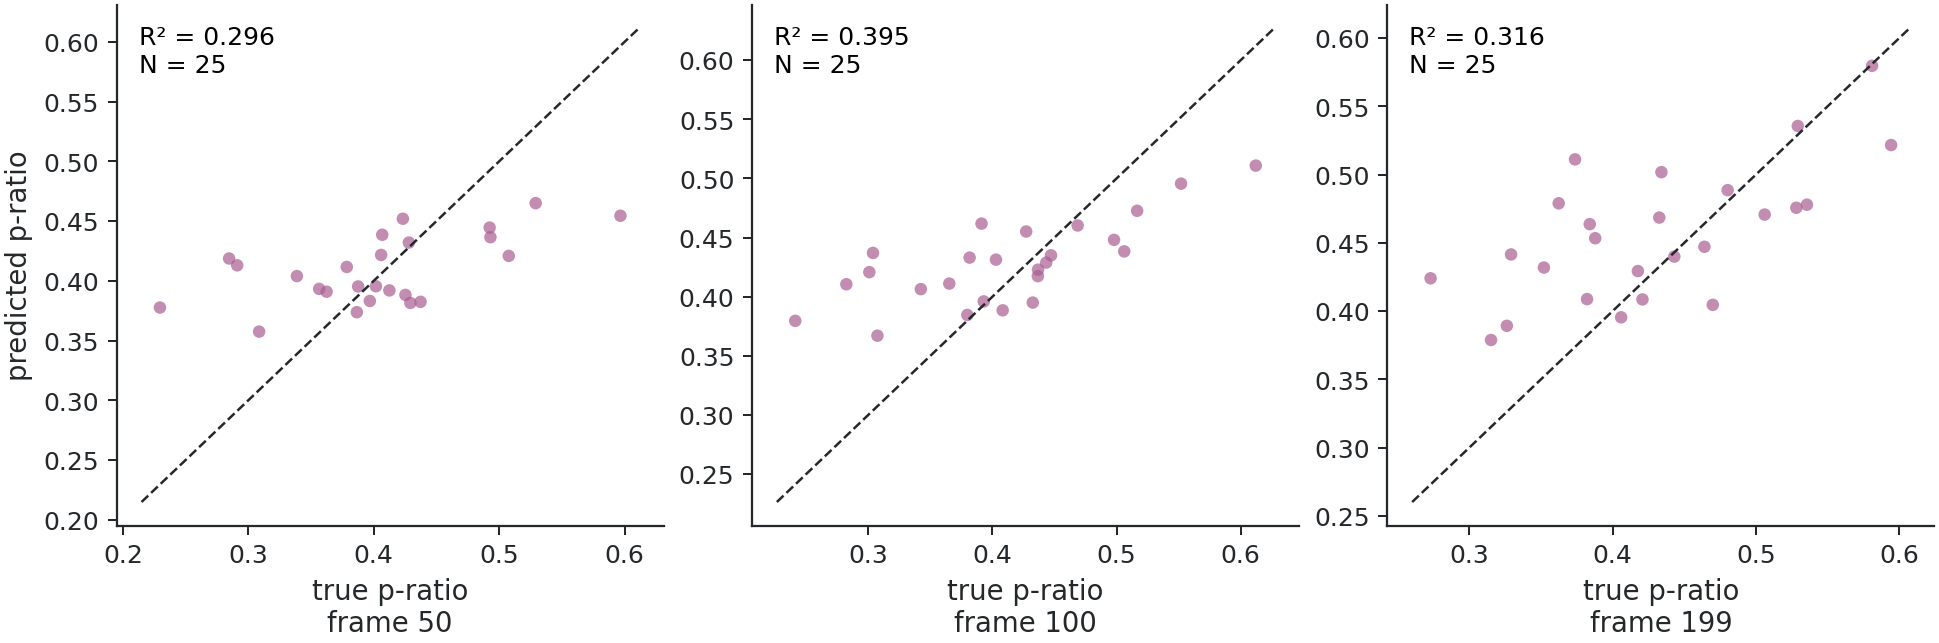

: 

In [ ]:
SCATTER_STEPS = [50, 100, 199]
fig, axes = plt.subplots(1, len(SCATTER_STEPS), figsize=(10.8, 3.6), constrained_layout=True)
for ax, step in zip(axes, SCATTER_STEPS):
    group = rollout[rollout.rollout_steps.eq(step)].replace([np.inf, -np.inf], np.nan).dropna(
        subset=['endpoint_true_p_ratio', 'endpoint_pred_p_ratio'])
    true = group.endpoint_true_p_ratio.to_numpy(float)
    pred = group.endpoint_pred_p_ratio.to_numpy(float)
    ax.scatter(true, pred, s=25, alpha=.7, color=dataset_color('lj_noisy'), edgecolor='none')
    if len(group):
        lo, hi = np.nanmin(np.r_[true, pred]), np.nanmax(np.r_[true, pred])
        pad = .04 * max(hi-lo, 1e-6)
        ax.plot([lo-pad, hi+pad], [lo-pad, hi+pad], '--', color=PAPER_COLORS['ink'], linewidth=1)
        score = r2_score(true, pred)
        ax.text(.04, .96, f'R² = {score:.3f}\nN = {len(group)}', transform=ax.transAxes, va='top')
    style_axes(ax, xlabel=f'true p-ratio\nframe {step}',
               ylabel='predicted p-ratio' if ax is axes[0] else '', legend=False)
plt.show()